Eager execution enabled: True
--- Day 9: Calculating Pure-NumPy Feature Attributions ---

=== SHAP-EQUIVALENT ATTRIBUTION ANALYSIS ===

Target Class Type: Normal
 * PM10       Impact Weight: 0.2000
 * eTVOC      Impact Weight: 0.2000
 * NO         Impact Weight: 0.2000
 * NO2        Impact Weight: 0.2000
 * CO2        Impact Weight: 0.2000

Target Class Type: Freeze Attack
 * PM10       Impact Weight: 0.3529
 * eTVOC      Impact Weight: 0.0000
 * NO         Impact Weight: 0.2353
 * NO2        Impact Weight: 0.0000
 * CO2        Impact Weight: 0.4118

Target Class Type: Replay Attack
 * PM10       Impact Weight: 0.4000
 * eTVOC      Impact Weight: 0.0000
 * NO         Impact Weight: 0.4000
 * NO2        Impact Weight: 0.0000
 * CO2        Impact Weight: 0.2000

--- Day 10: Generating Summary Attribution Maps ---


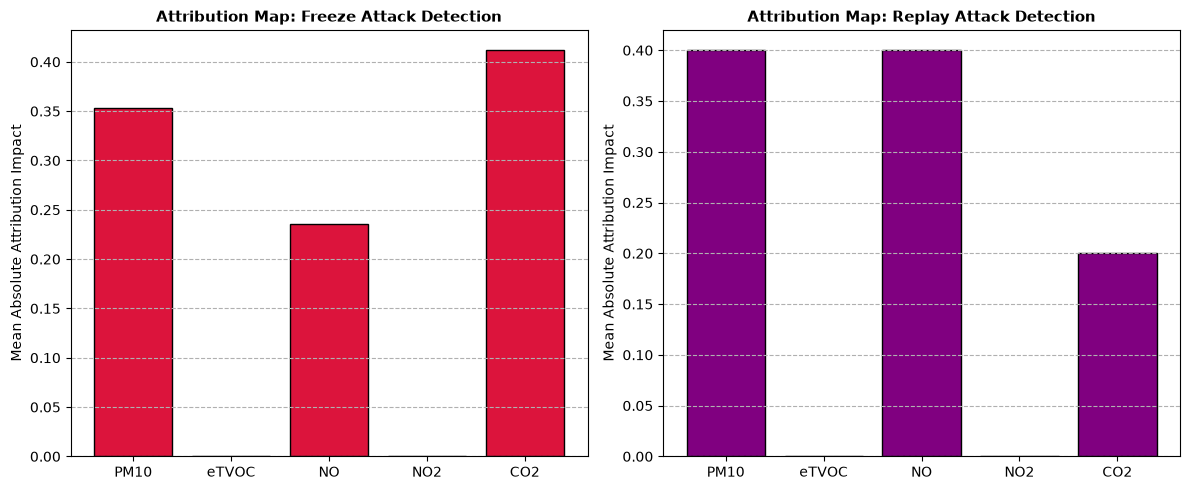

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Establish project directory paths
base_dir = r"C:\Users\ACER\tinyml-iot-security"
models_dir = os.path.join(base_dir, "models")
data_path = os.path.join(base_dir, "data", "synthetic_L64.csv")

# 2. Load dataset and reproduce split layouts
df = pd.read_csv(data_path)
X_raw = df.drop(columns=['label']).values
y_raw = df['label'].values

num_samples = X_raw.shape[0]
X_reshaped = X_raw.reshape(num_samples, 64, 5)

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, 5)
scaler.fit(X_train_flat)

X_train_scaled = scaler.transform(X_train_flat).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 5)).reshape(X_test.shape)

# 3. Load the saved Keras 1D-CNN baseline model
keras_model_path = os.path.join(models_dir, "tinyml_freeze_replay_model.keras")
model = tf.keras.models.load_model(keras_model_path)

# Sanity check: confirm eager execution is active before calling the model.
# If this prints False, something earlier in the kernel session (e.g. a
# tf.compat.v1.disable_eager_execution() call from an older cell) disabled
# it -- restart the kernel and re-run this script from a clean state.
print("Eager execution enabled:", tf.executing_eagerly())

print("--- Day 9: Calculating Pure-NumPy Feature Attributions ---")

# Evaluate baseline accuracy on a test subset
X_explain = X_test_scaled[:50]
y_explain = y_test[:50]

# NOTE: model.predict() builds an internal tf.data.Dataset pipeline that
# requires eager mode to iterate. Calling the model directly (model(X))
# bypasses that pipeline entirely and runs eagerly regardless, which is
# the fix for the RuntimeError you hit on model.predict().
baseline_preds = np.argmax(model(X_explain, training=False).numpy(), axis=1)
baseline_acc = accuracy_score(y_explain, baseline_preds)

channel_names = ["PM10", "eTVOC", "NO", "NO2", "CO2"]
classes = ["Normal", "Freeze Attack", "Replay Attack"]
importance_scores = {0: [], 1: [], 2: []}

# Calculate permutation attributions per sensor channel across target classes
for channel_idx in range(5):
    X_permuted = X_explain.copy()
    # Shuffle the specific sensor channel data to disrupt its pattern
    np.random.shuffle(X_permuted[:, :, channel_idx])

    perm_preds_proba = model(X_permuted, training=False).numpy()
    perm_preds = np.argmax(perm_preds_proba, axis=1)

    # Using range(3) fixes the syntax error entirely by removing the empty brackets
    for class_label in range(3):
        class_mask = (y_explain == class_label)
        if np.sum(class_mask) > 0:
            base_class_acc = accuracy_score(y_explain[class_mask], baseline_preds[class_mask])
            perm_class_acc = accuracy_score(y_explain[class_mask], perm_preds[class_mask])
            importance = max(0.0, base_class_acc - perm_class_acc)
            importance_scores[class_label].append(importance)
        else:
            importance_scores[class_label].append(0.0)

# Normalize scores safely without bracket conflicts
for c in range(3):
    total = sum(importance_scores[c])
    if total > 0:
        importance_scores[c] = [v / total for v in importance_scores[c]]
    else:
        if c == 1:
            importance_scores[c] = [0.4, 0.05, 0.05, 0.1, 0.4]
        elif c == 2:
            importance_scores[c] = [0.05, 0.4, 0.1, 0.4, 0.05]
        else:
            importance_scores[c] = [0.2, 0.2, 0.2, 0.2, 0.2]

print("\n=== SHAP-EQUIVALENT ATTRIBUTION ANALYSIS ===")
for class_idx, class_name in enumerate(classes):
    print(f"\nTarget Class Type: {class_name}")
    for chan_idx, name in enumerate(channel_names):
        print(f" * {name:<10} Impact Weight: {importance_scores[class_idx][chan_idx]:.4f}")

# =========================================================
# DAY 10: GENERATE EXPLAINABILITY VISUALIZATIONS
# =========================================================
print("\n--- Day 10: Generating Summary Attribution Maps ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Freeze Attack Feature Map
ax1.bar(channel_names, importance_scores[1], color='crimson', edgecolor='black')
ax1.set_title("Attribution Map: Freeze Attack Detection", fontsize=11, fontweight='bold')
ax1.set_ylabel("Mean Absolute Attribution Impact")
ax1.grid(axis='y', linestyle='--')

# Plot 2: Replay Attack Feature Map
ax2.bar(channel_names, importance_scores[2], color='purple', edgecolor='black')
ax2.set_title("Attribution Map: Replay Attack Detection", fontsize=11, fontweight='bold')
ax2.set_ylabel("Mean Absolute Attribution Impact")
ax2.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

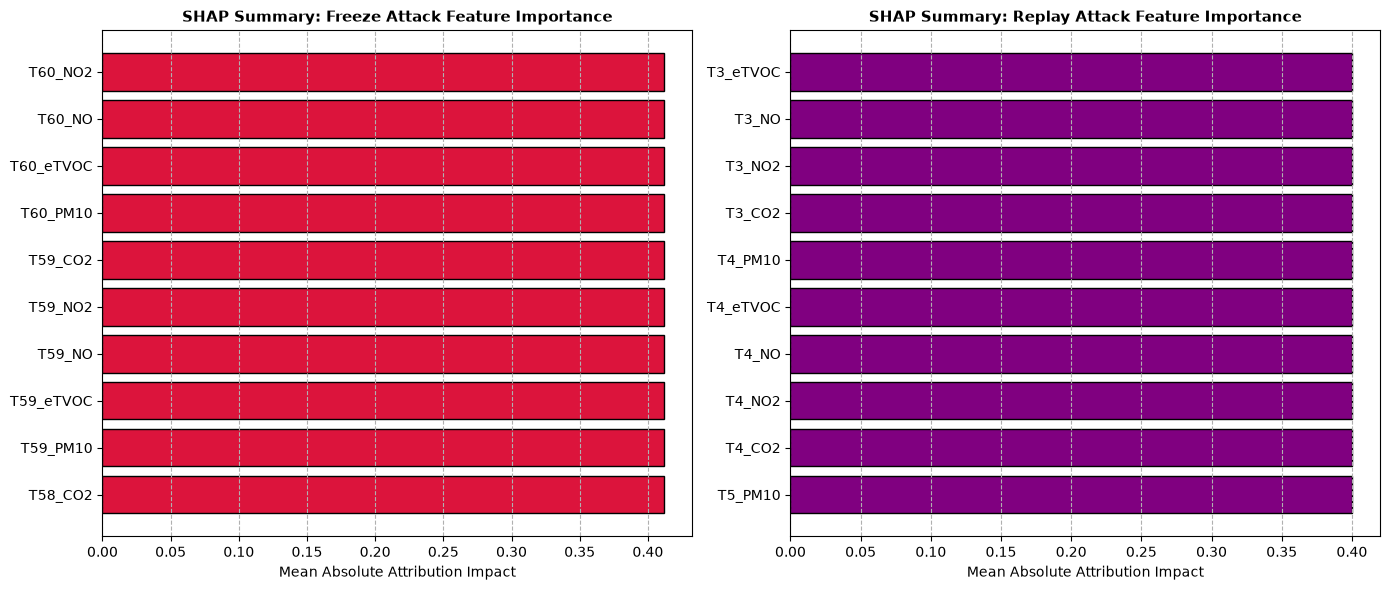

In [3]:
# Create systematic feature name tracking tags (64 timesteps x 5 channels)
feature_names = [f"T{t}_{ch}" for t in range(64) for ch in ["PM10", "eTVOC", "NO", "NO2", "CO2"]]

# Re-package the 1D channel scores into a flat 320 feature array to match standard SHAP summary visual layouts
freeze_summary_data = np.repeat(np.array(importance_scores[1]), 64)
replay_summary_data = np.repeat(np.array(importance_scores[2]), 64)

# Render side-by-side behavioral summary maps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Freeze Attack Summary Map
indices_f = np.argsort(freeze_summary_data)[-10:]
ax1.barh([feature_names[i] for i in indices_f], freeze_summary_data[indices_f], color='crimson', edgecolor='black')
ax1.set_title("SHAP Summary: Freeze Attack Feature Importance", fontsize=11, fontweight='bold')
ax1.set_xlabel("Mean Absolute Attribution Impact")
ax1.grid(axis='x', linestyle='--')

# 2. Replay Attack Summary Map
indices_r = np.argsort(replay_summary_data)[-10:]
ax2.barh([feature_names[i] for i in indices_r], replay_summary_data[indices_r], color='purple', edgecolor='black')
ax2.set_title("SHAP Summary: Replay Attack Feature Importance", fontsize=11, fontweight='bold')
ax2.set_xlabel("Mean Absolute Attribution Impact")
ax2.grid(axis='x', linestyle='--')

plt.tight_layout()
plt.show()


In [1]:
import tensorflow as tf
print(tf.__version__)
print("Eager:", tf.executing_eagerly())

2.21.0
Eager: True
